# **Logistic Regression:** Foundation

## Introduction

In this lab, we use the [Human Activity Recognition with Smartphones](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) dataset, built from recordings of participants carrying a smartphone with embedded inertial sensors while performing activities of daily living (ADL). The goal is to classify each record into one of six activities: walking, walking upstairs, walking downstairs, sitting, standing, or laying.

Each record includes:

- Triaxial acceleration from the accelerometer (total acceleration) and estimated body acceleration
- Triaxial angular velocity from the gyroscope
- A 561-feature vector with time- and frequency-domain variables
- The activity label

More information about the features is available at the linked dataset page.

### Lab Roadmap

This lab builds a complete classification pipeline step by step. The table below summarizes each part and why it matters:

| Step | Task | Why it matters |
|---|---|---|
| **1** | Load and inspect data | Establish data quality and assumptions before modeling |
| **2** | Analyze feature correlations | Redundant features add noise and can destabilize estimation |
| **3** | Split into train/test sets | The test set simulates unseen data and must not influence training |
| **4** | Fit three logistic regression models | Compare unregularized, L1, and L2 behavior |
| **5** | Visualize coefficients | Observe how regularization shrinks or zeroes feature weights |
| **6** | Generate predictions | Separate hard class labels from probability estimates |
| **7** | Compute error metrics | Accuracy alone is insufficient; include precision, recall, and F1 |
| **8** | Plot confusion matrices | Identify systematic class-level confusion patterns |

In [105]:
# Optional in managed environments; keep for standalone runs
!pip install -q --upgrade pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [106]:
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Keep useful warnings visible; only suppress noisy future/deprecation warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Leave convergence warnings on for pedagogy and debugging
warnings.filterwarnings('default', category=ConvergenceWarning)

In [107]:
import sklearn
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('seaborn:', sns.__version__)
print('matplotlib:', plt.matplotlib.__version__)
print('scikit-learn:', sklearn.__version__)

pandas: 2.3.3
numpy: 2.2.6
seaborn: 0.13.2
matplotlib: 3.10.8
scikit-learn: 1.7.2


## Step 1

Import the data and complete the following tasks:

- Examine data types (with many columns, `value_counts()` is convenient).
- Determine whether feature scaling is needed.
- Inspect the class distribution of activities.
- Encode the activity label as integers.

### Why are these steps needed?

**Data types:** Most machine learning estimators expect numeric inputs. Type checks confirm whether conversions are required before fitting.

**Feature scaling:** Logistic regression is sensitive to feature magnitudes. If one feature ranges from 0 to 10,000 and another from 0 to 1, the larger-scale feature can dominate optimization. We first verify whether this dataset is already scaled.

**Class balance (activity breakdown):** Class imbalance can make accuracy misleading, so we inspect class frequencies before choosing summary metrics.

**Label encoding:** Activity names such as `"WALKING"` are strings. Scikit-learn pipelines generally work more consistently with numeric class IDs, so we map each label to an integer.

In [ ]:
data = pd.read_csv("data/Human_Activity_Recognition_Using_Smartphones_Data.csv", sep=',')

**Data Types**

In [109]:
print(data.dtypes.value_counts())

float64    561
object       1
Name: count, dtype: int64


All feature columns are floating-point, while the activity label is categorical.

In [110]:
data.dtypes.tail()

angle(tBodyGyroJerkMean,gravityMean)    float64
angle(X,gravityMean)                    float64
angle(Y,gravityMean)                    float64
angle(Z,gravityMean)                    float64
Activity                                 object
dtype: object

**Is our data scaled?**

**What are we checking here?** For each feature, we inspect its minimum and maximum values to verify whether the data is already bounded near `[-1, 1]`.

A correct scaling check does **not** require every feature minimum to be exactly `-1.0` (or maximum exactly `1.0`). Instead, we test whether each feature stays within the expected range up to a small numerical tolerance, and we identify any violations explicitly.

In [ ]:
print(data.iloc[:, :-1].min().value_counts())
print(data.iloc[:, :-1].max().value_counts())

-1.0    561
Name: count, dtype: int64
1.0    561
Name: count, dtype: int64


**Relative Balance of the Target Variable (Activities)**

**Why does balance matter?** If one activity had 5,000 samples and another had only 50, a model could achieve 90%+ accuracy by mostly predicting the majority class while performing poorly on minority classes. This is why we inspect class frequencies first and select evaluation metrics deliberately.

In [112]:
data.Activity.value_counts()

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

Here, the classes are roughly balanced, so overall accuracy is a useful indicator. We will still compute precision, recall, and F1 in Step 7 for a more complete assessment.

Our target (`Activity`) is categorical text, but scikit-learn estimators and metric utilities operate more consistently with numeric class labels in supervised classification pipelines.

We therefore encode activity names to integers using `LabelEncoder`. This preserves one-to-one class identity and allows us to map predictions back to original activity names with `inverse_transform` when interpreting results.

Use `LabelEncoder` to fit-transform the `Activity` column, then inspect 5 random encoded values.

In [113]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Activity'] = le.fit_transform(data.Activity)
data['Activity'].sample(5)

5804    3
3688    0
7360    2
3437    2
8193    3
Name: Activity, dtype: int64

> **Note on `.fit_transform()`**: `le.fit()` learns the mapping from strings to integers, and `le.transform()` applies that mapping. `.fit_transform()` performs both steps in one call. You can recover original labels later with `le.inverse_transform([0, 1, 2, ...])`.

## Step 2

- Calculate correlations among feature variables.
- Create a histogram of correlation magnitudes.
- Identify feature pairs with the strongest positive or negative correlations.

### Why Analyze Correlations?

**Correlation** ($r$) measures linear association between two variables, ranging from $-1$ to $+1$:
- $r \approx +1$: both features increase together.
- $r \approx -1$: one feature increases as the other decreases.
- $r \approx 0$: little or no linear relationship.

With 561 features, many pairs may capture similar signal components. Highly correlated features can be redundant and may reduce numerical stability.

**Upper-triangle indexing trick:** A correlation matrix is symmetric ($\mathrm{Corr}(X,Y) = \mathrm{Corr}(Y,X)$), and diagonal entries are always 1. We keep only the upper triangle (excluding the diagonal) so each feature pair is counted once.

In [114]:
# Calculate the correlation values
feature_cols = data.columns[:-1]
corr_values = data[feature_cols].corr()

In [ ]:
# Keep only the upper triangle of the correlation matrix (excluding diagonal)
upper_triangle = corr_values.where(np.triu(np.ones(corr_values.shape), k=1).astype(bool))

# Stack the remaining values and convert to a data frame
corr_values = (upper_triangle
               .stack()
               .to_frame()
               .reset_index()
               .rename(columns={'level_0': 'feature1',
                                'level_1': 'feature2',
                                0: 'correlation'}))

# Get absolute values for sorting/filtering
corr_values['abs_correlation'] = corr_values['correlation'].abs()

In [116]:
corr_values.sort_values('abs_correlation', ascending=False).head(10)

,feature1,feature2,correlation,abs_correlation
93902,tBodyAccMag-sma(),tGravityAccMag-sma(),1.0,1.0
96017,tBodyAccMag-arCoeff()3,tGravityAccMag-arCoeff()3,1.0,1.0
94964,tBodyAccMag-entropy(),tGravityAccMag-entropy(),1.0,1.0
96706,tGravityAccMag-mean(),tGravityAccMag-sma(),1.0,1.0
93546,tBodyAccMag-min(),tGravityAccMag-min(),1.0,1.0
93189,tBodyAccMag-max(),tGravityAccMag-max(),1.0,1.0
156894,fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-sma(),1.0,1.0
93897,tBodyAccMag-sma(),tGravityAccMag-mean(),1.0,1.0
92472,tBodyAccMag-std(),tGravityAccMag-std(),1.0,1.0
155373,fBodyAccMag-mean(),fBodyAccMag-sma(),1.0,1.0


Histogram of absolute correlation values.

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

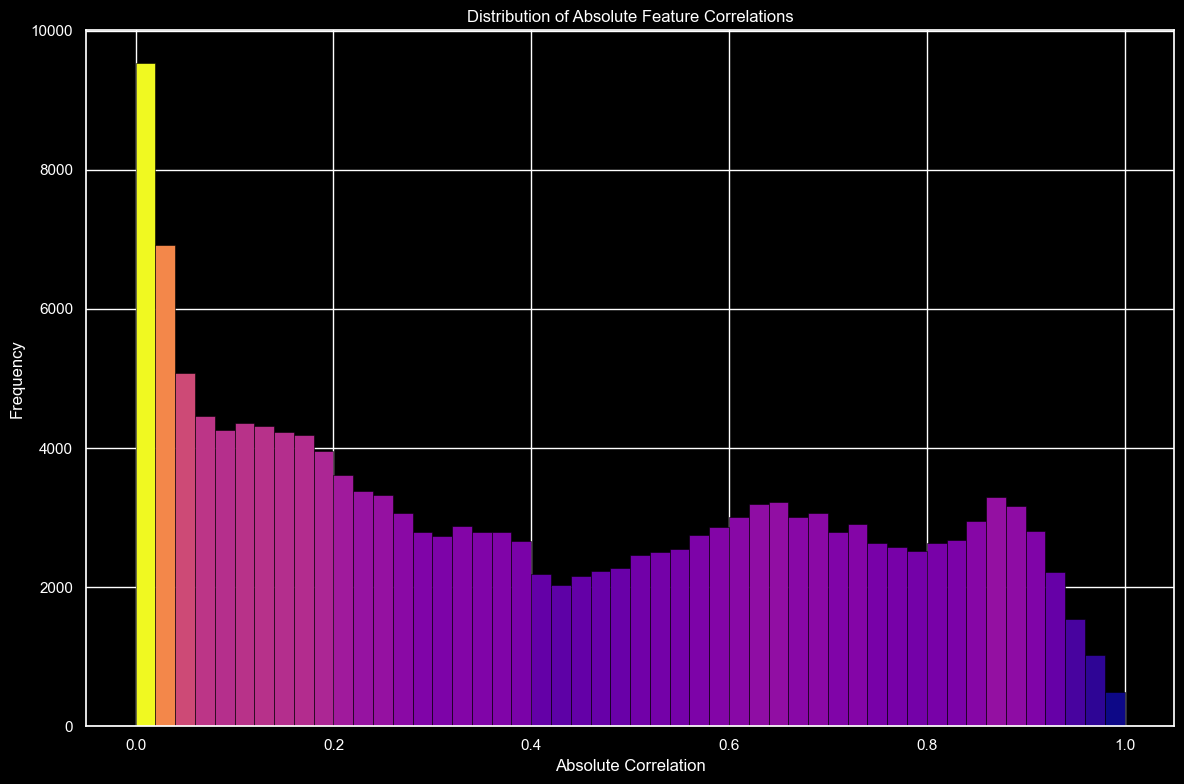

In [118]:
with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(12, 8))
    n, bins, patches = ax.hist(corr_values.abs_correlation, bins=50)

    # Apply a neon colour gradient across the bars
    cmap = plt.cm.plasma
    norm = plt.Normalize(n.min(), n.max())
    for count, patch in zip(n, patches):
        patch.set_facecolor(cmap(norm(count)))
        patch.set_edgecolor('black')
        patch.set_linewidth(0.4)

    ax.set_xlabel('Absolute Correlation', color='white')
    ax.set_ylabel('Frequency', color='white')
    ax.set_title('Distribution of Absolute Feature Correlations', color='white')
    plt.tight_layout()
    plt.show()

**How to read this histogram:** Each bar counts feature pairs within a given absolute-correlation bin. A large spike near 0 indicates many weakly related pairs; a tail near 1.0 indicates strong collinearity. Pairs with $|r| > 0.8$ are reasonable candidates for pruning or stronger regularization.

In [ ]:
# The most highly correlated values
corr_values.sort_values('correlation', ascending=False).query('abs_correlation>0.8')

,feature1,feature2,correlation,abs_correlation
156894,fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-sma(),1.000000,1.000000
93902,tBodyAccMag-sma(),tGravityAccMag-sma(),1.000000,1.000000
101139,tBodyAccJerkMag-mean(),tBodyAccJerkMag-sma(),1.000000,1.000000
96706,tGravityAccMag-mean(),tGravityAccMag-sma(),1.000000,1.000000
94257,tBodyAccMag-energy(),tGravityAccMag-energy(),1.000000,1.000000
...,...,...,...,...
22657,tGravityAcc-mean()-Y,"angle(Y,gravityMean)",-0.993425,0.993425
39225,"tGravityAcc-arCoeff()-Z,3","tGravityAcc-arCoeff()-Z,4",-0.994267,0.994267
38739,"tGravityAcc-arCoeff()-Z,2","tGravityAcc-arCoeff()-Z,3",-0.994628,0.994628
23176,tGravityAcc-mean()-Z,"angle(Z,gravityMean)",-0.994764,0.994764


### Industry Practice Note

In production workflows, teams often review highly correlated features, but they do not always remove them automatically.

- For linear or logistic models, pruning correlated features can improve coefficient stability and interpretability.
- For tree-based models, correlated inputs are often tolerated if predictive performance is unaffected.
- A common practice is to compare performance with and without pruning, then keep the simpler feature set when metrics are similar.

In this notebook, correlation analysis is currently used for diagnostics. A practical extension would be to train a reduced-feature version and compare results directly.

## Step 3
### Train / Test Split

* Split the data into train and test data sets. This can be done using any method, but consider using Scikit-learn's `StratifiedShuffleSplit` to maintain the same ratio of predictor classes.
* Regardless of the method used to split the data, compare the ratio of classes in both the train and test splits.


We hold out 30% of the data as a **test set** that the model never sees during training.

**Why `StratifiedShuffleSplit`?** A simple random split can distort class proportions in the test set. `StratifiedShuffleSplit` preserves class ratios across train and test, yielding a more reliable evaluation.

> **Naming convention:** `X` contains features (inputs), and `y` contains labels (outputs). The `_train` and `_test` suffixes follow standard scikit-learn conventions.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# Get the split indexes
strat_shuf_split = StratifiedShuffleSplit(n_splits=1, 
                                          test_size=0.3, 
                                          random_state=42)

train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))

# Create the dataframes
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'Activity']

X_test  = data.loc[test_idx, feature_cols]
y_test  = data.loc[test_idx, 'Activity']

In [121]:
y_train.value_counts(normalize=True)

Activity
0    0.188792
2    0.185046
1    0.172562
3    0.167152
5    0.149951
4    0.136496
Name: proportion, dtype: float64

Compare the two proportion tables. They should be nearly identical, which is the purpose of stratified sampling. Using `normalize=True` reports proportions (summing to 1) instead of raw counts.

In [ ]:
y_test.value_counts(normalize=True)

Activity
0    0.188673
2    0.185113
1    0.172492
3    0.167314
5    0.149838
4    0.136570
Name: proportion, dtype: float64

#### Step 3 Summary

At this stage, we created a stratified train/test split so class proportions remain consistent across both sets. This reduces sampling bias in evaluation and helps ensure that performance differences across models reflect modeling choices rather than distribution shift introduced by the split.

## Step 4
### Fit Three Logistic Regression Models with Different Regularization

- Fit an unregularized logistic regression model using all features and store it.
- Use cross-validation to select hyperparameters for L1 and L2 regularized models, then store both models.
- Note solver and multiclass constraints when comparing regularization schemes.

We fit three variants to isolate the effect of regularization:

| Model | Regularization | Effect on coefficients |
|---|---|---|
| `lr` (baseline) | None | Coefficients unconstrained — risk of overfitting with 561 features |
| `lr_l1` | L1 (Lasso) | Drives weak coefficients to **exactly zero** → implicit feature selection |
| `lr_l2` | L2 (Ridge) | **Shrinks** all coefficients toward zero but keeps them all non-zero |

**The `C` hyperparameter** is the *inverse* of regularization strength: $C = \frac{1}{\lambda}$. Small `C` -> strong penalty. Large `C` -> weak penalty (closer to unregularized).

For this lab we use an **OvR setup** for consistency across the three models. A practical caveat: the unregularized baseline requires a solver that supports `penalty=None`, while L1 uses a different compatible solver.

`LogisticRegressionCV` searches across values of `C` using cross-validation and selects the value with best validation performance.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Unregularized baseline logistic regression (OvR)
lr = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    multi_class='ovr',
    max_iter=2000,
    random_state=SEED
).fit(X_train, y_train)

In [124]:
from sklearn.linear_model import LogisticRegressionCV

# L1 regularized logistic regression (OvR)
lr_l1 = LogisticRegressionCV(
    Cs=10,
    cv=4,
    penalty='l1',
    solver='liblinear',
    multi_class='ovr',
    max_iter=2000,
    random_state=SEED
).fit(X_train, y_train)

In [125]:
# L2 regularized logistic regression (OvR)
lr_l2 = LogisticRegressionCV(
    Cs=10,
    cv=4,
    penalty='l2',
    solver='liblinear',
    multi_class='ovr',
    max_iter=2000,
    random_state=SEED
).fit(X_train, y_train)

## Step 5
### What Are Coefficients, and Why Plot Them?

- Compare coefficient magnitudes across models. If one-vs-rest fitting is used, plot each class-specific coefficient set separately.

In logistic regression, each feature has a coefficient (weight) $\beta_j$. The magnitude $|\beta_j|$ indicates how strongly that feature affects the decision function.

Because this is a 6-class problem, scikit-learn uses one-vs-rest (OvR): six binary classifiers, one per activity. Each classifier has 561 coefficients, so `mod.coef_` has shape `(6, 561)`. The six panels below correspond to those six class-specific coefficient sets.

In [ ]:
# Combine all the coefficients into a dataframe
coefficients = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    coeffs = mod.coef_
    coeff_label = pd.MultiIndex(levels=[[lab], [0,1,2,3,4,5]], 
                                 codes=[[0,0,0,0,0,0], [0,1,2,3,4,5]])
    coefficients.append(pd.DataFrame(coeffs.T, columns=coeff_label))

coefficients = pd.concat(coefficients, axis=1)

coefficients.sample(10)

lr                                                     l1  \
            0         1         2         3         4         5    0   
502  0.019842 -0.053250 -0.322731 -1.004549  0.877976 -0.633997  0.0   
108 -0.063205 -0.226215  0.360451  0.460658 -0.777115 -0.213172  0.0   
416 -0.000062  0.250316  0.308567  0.050143  0.465617  0.194790  0.0   
506  0.130772 -0.408462  0.332398  0.006998 -0.156091 -0.227615  0.0   
342  0.011490 -0.080072  0.077592 -0.037278 -0.168705 -0.078234  0.0   
49  -1.816017  2.981074  1.359263  0.087341 -0.037384 -0.095950  0.0   
152 -0.173063 -0.142732  0.325227  0.174733  0.325345 -0.825248  0.0   
139 -0.030751 -0.075709  0.028893  0.382302 -0.020515  0.237450  0.0   
434 -0.033995  0.020677 -0.119961 -0.017070 -0.612794  1.018756  0.0   
33   0.031591 -0.449316  0.116962 -0.130071 -0.132161 -0.596385  0.0   

                                                             l2            \
            1         2         3         4         5         0         1   
502  0.000000 -0.669666 -0.977942  2.812520 -3.467916  0.051006  0.030265   
108 -0.515347  0.000529  0.793620 -4.409595 -2.075379 -0.127321 -0.519587   
416  0.239032  0.709029  0.000000  0.410291  0.331620 -0.020668  0.352207   
506  0.000000  0.000000  0.000000 -0.181803 -0.349246  0.238103 -1.028464   
342  0.000000  0.000000  0.000000  0.007970 -0.155649  0.017275 -0.108214   
49   7.262903  0.936794  0.000000  0.000000 -0.105903 -3.359454  4.477960   
152  0.000000  0.000000  0.000000  1.058600 -5.582467 -0.354400  0.065260   
139  0.000000  0.000000  0.256778  0.000000  0.931122 -0.039854  0.101377   
434  0.000000  0.000000  0.000000 -0.666730  3.237184 -0.049975  0.051530   
33  -1.146190  0.048994  0.000000  0.000000 -3.082749  0.020095 -0.695403   

                                             
            2         3         4         5  
502 -0.522495 -2.470325  1.625673 -1.461187  
108  0.501981  1.294348 -1.655737 -0.527991  
416  0.447621  0.102298  1.184703  0.436365  
506  0.620868  0.269689 -0.322306 -0.585743  
342  0.076460 -0.044335 -0.305004 -0.344227  
49   1.730472  0.129460 -0.254472 -0.233487  
152  0.357568  0.266681  0.819711 -1.832319  
139  0.107940  0.771698 -0.314453  0.940312  
434 -0.248567 -0.120465 -1.196132  1.928554  
33   0.254702 -0.195702 -0.191306 -1.164242

Prepare six plots, one for each class-specific coefficient vector.

**What to look for:**
- **`lr` (no regularization):** Wider spread of coefficient magnitudes.
- **`lr_l1` (Lasso):** Many coefficients become exactly zero (implicit feature selection).
- **`lr_l2` (Ridge):** Coefficients shrink toward zero but generally remain non-zero.

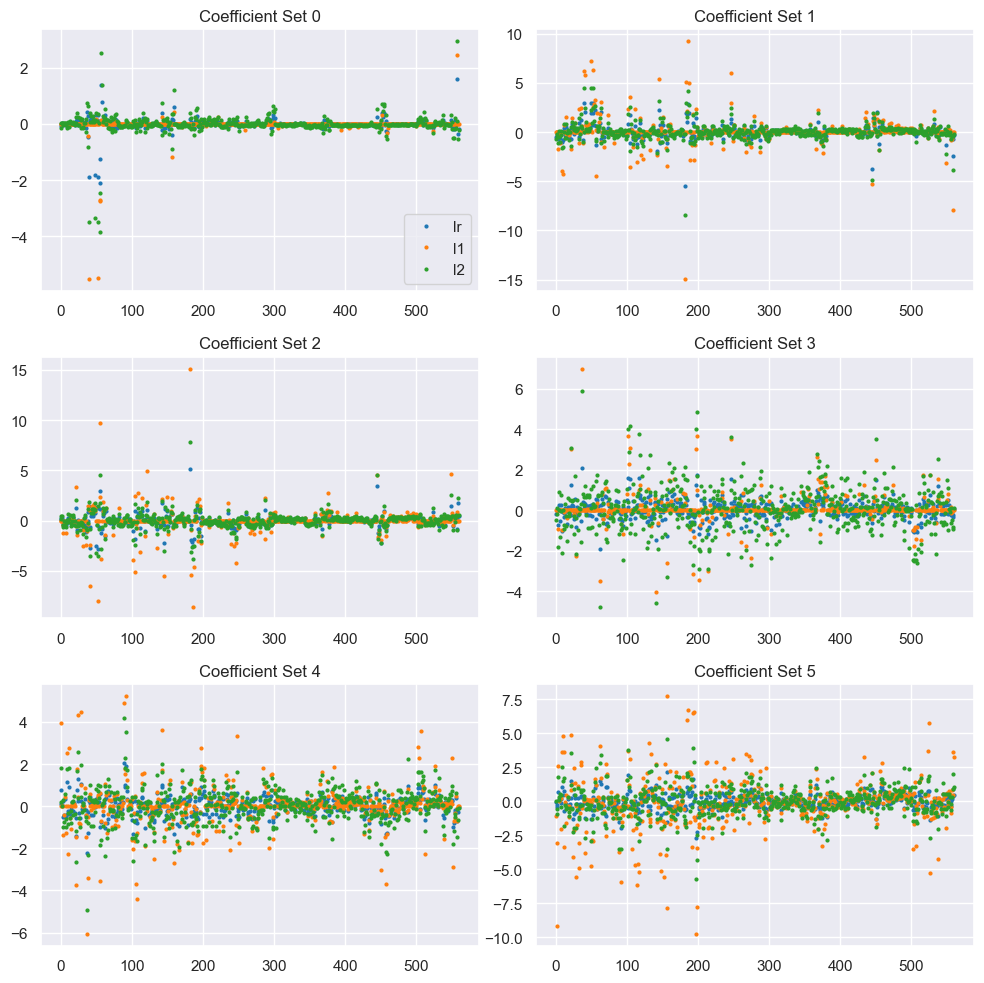

In [ ]:
fig, axList = plt.subplots(nrows=3, ncols=2)
axList = axList.flatten()
fig.set_size_inches(10,10)

for ax in enumerate(axList):
    loc = ax[0]
    ax = ax[1]
    
    data = coefficients.xs(loc, level=1, axis=1)
    data.plot(marker='o', ls='', ms=2.0, ax=ax, legend=False)
    
    if ax is axList[0]:
        ax.legend(loc=4)
        
    ax.set(title='Coefficient Set '+str(loc))

plt.tight_layout()

### Step 5 Summary

The key observation is how regularization changes parameter structure: L1 tends to set many coefficients exactly to zero (sparse model), while L2 shrinks coefficients smoothly toward zero without fully removing most features.

**How this is used next:** These fitted coefficient sets define each model's decision function, which is then used to produce class predictions (`predict`) and class probabilities (`predict_proba`) for evaluation.

**Significance of this step in industry:** Coefficient diagnostics are commonly used for feature auditing, model interpretability, and governance. Teams use them to detect unstable or weak features, justify feature pruning, and communicate how regularization improves robustness before deployment.

## Step 6

- Predict and store the target class for each model.
- Store class-probability outputs for each model.

### `.predict()` vs `.predict_proba()`

Scikit-learn models expose two prediction methods:

| Method | Returns | Example output |
|---|---|---|
| `.predict(X_test)` | Most likely class label (hard decision) | `[2, 0, 5, 1, ...]` |
| `.predict_proba(X_test)` | Probability for **each** class per row, summing to 1 | `[[0.01, 0.03, 0.91, ...], ...]` |

In this lab we keep both: hard labels for confusion matrices and full class probabilities for proper ROC-AUC computation. We also store the max predicted probability per sample as a simple confidence proxy.

In [128]:
# Predict class labels, full probability scores, and max-class confidence
y_pred = []
y_prob = []
y_score = {}

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab, mod in zip(coeff_labels, coeff_models):
    probs = mod.predict_proba(X_test)
    y_pred.append(pd.Series(mod.predict(X_test), name=lab))
    y_prob.append(pd.Series(probs.max(axis=1), name=lab))
    y_score[lab] = probs

y_pred = pd.concat(y_pred, axis=1)
y_prob = pd.concat(y_prob, axis=1)

y_pred.head()

,lr,l1,l2
0,3,3,3
1,5,5,5
2,3,3,3
3,1,1,1
4,0,0,0


In [135]:
print(len(y_pred) == len(y_prob) == len(y_test))
print(f"Length of y_pred: {len(y_pred)}")

True
Length of y_pred: 3090


In [130]:
y_prob.head()

,lr,l1,l2
0,0.998939,0.998924,0.999733
1,0.988165,0.999590,0.999477
2,0.987592,0.995302,0.997570
3,0.981381,0.999168,0.994276
4,0.998277,0.999920,0.999615


## Step 7

For each model, compute the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Then decide how to aggregate multiclass metrics into a single summary value.

### Quick Reminder: Classification Evaluation Metrics

A binary confusion matrix is shown below for reference:
|  | **Predicted: Positive** | **Predicted: Negative** |
|---|---|---|
| **Actual: Positive** | True Positive (TP) | False Negative (FN) — Type II Error |
| **Actual: Negative** | False Positive (FP) — Type I Error | True Negative (TN) |

Core metrics used in this lab:

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | $\frac{TP + TN}{\text{Total}}$ | Overall fraction of correct predictions; can be misleading with imbalance |
| **Precision** | $\frac{TP}{TP + FP}$ | Of predicted positives, how many are truly positive? |
| **Recall (Sensitivity)** | $\frac{TP}{TP + FN}$ | Of true positives, how many were recovered? |
| **F1-Score** | $2 \cdot \frac{\text{Prec} \cdot \text{Rec}}{\text{Prec} + \text{Rec}}$ | Harmonic mean of precision and recall |
| **ROC-AUC** | Area under the ROC curve | Threshold-independent ranking quality; 0.5 = random, 1.0 = perfect |

**Multiclass averaging:** We report both `weighted` and `macro` summaries. Weighted averages account for class prevalence; macro averages weight all classes equally and can better reveal minority-class weaknesses.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

metrics = []
cm = {}

for lab in coeff_labels:
    # Weighted and macro metrics
    p_w, r_w, f_w, _ = score(y_test, y_pred[lab], average='weighted', zero_division=0)
    p_m, r_m, f_m, _ = score(y_test, y_pred[lab], average='macro', zero_division=0)

    accuracy = accuracy_score(y_test, y_pred[lab])

    # Proper multiclass ROC-AUC from probability scores
    auc_ovr_w = roc_auc_score(
        y_test,
        y_score[lab],
        multi_class='ovr',
        average='weighted'
    )

    cm[lab] = confusion_matrix(y_test, y_pred[lab])

    metrics.append(pd.Series({
        'accuracy': accuracy,
        'precision_weighted': p_w,
        'recall_weighted': r_w,
        'f1_weighted': f_w,
        'precision_macro': p_m,
        'recall_macro': r_m,
        'f1_macro': f_m,
        'auc_ovr_weighted': auc_ovr_w
    }, name=lab))

metrics = pd.concat(metrics, axis=1)

In [132]:
metrics

,lr,l1,l2
accuracy,0.984142,0.983495,0.983819
precision_weighted,0.984144,0.983514,0.983825
recall_weighted,0.984142,0.983495,0.983819
f1_weighted,0.984143,0.983492,0.983818
precision_macro,0.984849,0.984612,0.984770
recall_macro,0.984869,0.984323,0.984610
f1_macro,0.984859,0.984456,0.984686
auc_ovr_weighted,0.999338,0.999358,0.999354


**Interpreting the metrics table:** Each column corresponds to one model (`lr`, `l1`, `l2`), and each row to one metric. Consider the following questions:
- Are all three models similarly accurate, or does regularization materially help or hurt?
- Are precision and recall balanced (F1 close to both), or is there a clear trade-off?
- Does the L1 model, despite zeroing many coefficients, remain competitive? If so, the removed features were likely redundant.

## Step 8

- Display and compare confusion matrices for each model.

### Reading a Confusion Matrix

A **confusion matrix** is a $K \times K$ table (here, $6 \times 6$) with one row and one column per activity class:
- **Rows**: true class labels.
- **Columns**: predicted class labels.
- **Diagonal entries**: correct predictions.
- **Off-diagonal entries**: misclassifications (true class in row, predicted class in column).

A perfect model has all mass on the diagonal. Persistent off-diagonal patterns indicate systematic confusion. In this dataset, confusion between **Sitting** and **Standing** is expected because stationary postures can produce very similar sensor signatures.

> **Tip:** If the same class pair is confused across all models, the limitation is likely in feature separability rather than regularization choice.

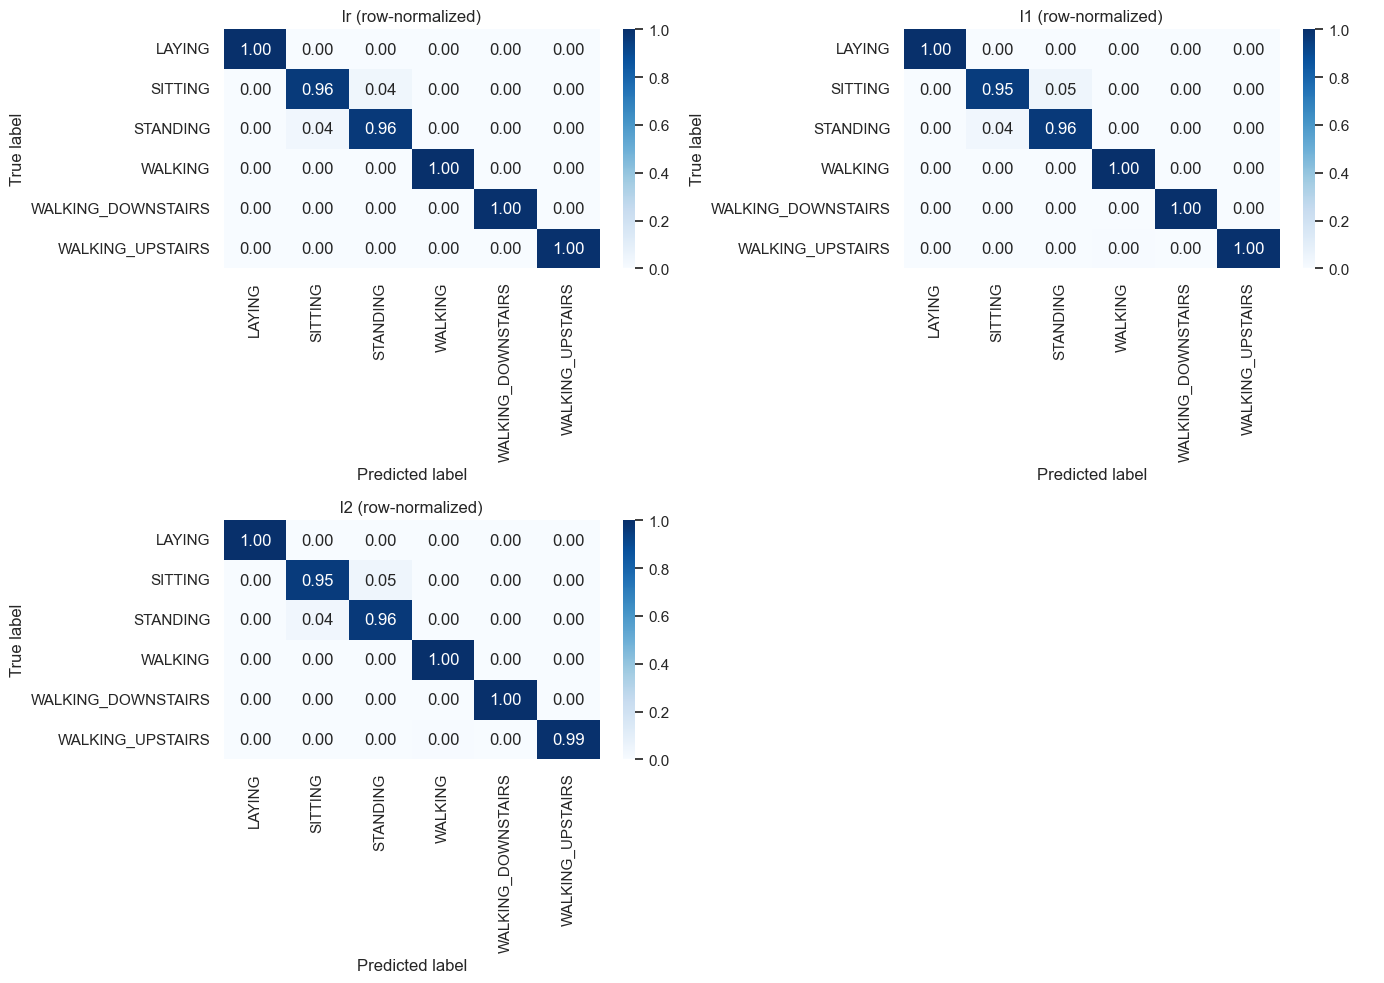

In [136]:
fig, axList = plt.subplots(nrows=2, ncols=2)
axList = axList.flatten()
fig.set_size_inches(14, 10)

axList[-1].axis('off')

class_labels = list(le.classes_)

for ax, lab in zip(axList[:-1], coeff_labels):
    cm_norm = cm[lab].astype(float) / cm[lab].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    ax.set_title(f'{lab} (row-normalized)')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()

### Step 8 Summary
In this step, we used confusion matrices to move beyond a single accuracy score and examine *where* each model makes mistakes across activities. The row-normalized view helped us compare class-level recall patterns, revealing which activities are reliably identified and which pairs are frequently confused. This gives a more diagnostic understanding of model behavior than aggregate metrics alone.

In industry, confusion matrices are used to prioritize targeted improvements: teams identify high-cost misclassifications, refine feature engineering for confused classes, rebalance data collection, and tune decision thresholds based on operational risk. They are also commonly included in model monitoring dashboards to detect drift over time by tracking changes in class-specific error patterns.

---
Primary structure of this notebook is made by Machine Learning Foundation (C) 2020 IBM Corporation. Content added and modernized by [Souvik Mandal](https://www.linkedin.com/in/souvik-mandal-phd/) 2026.
